# Predicción de Defectos en Extrusión de Plástico — Plastigama

Prototipo de Machine Learning para clasificar piezas plásticas como *sin defecto* (1) o *con defecto* (0) a partir de variables del proceso de extrusión.

Algoritmos evaluados:
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)


## Configuraciones iniciales
Importación de librerías, definición de constantes y configuración de visualización

### Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)


### Constantes

In [2]:
DATASET_PATH = "dataset/dataset.csv"

FEATURES = [
    "temperatura del barril",
    "presion",
    "velocidad del tornillo",
    "tiempo del ciclo",
    "mezcla",
    "categoria de producto",
]

TARGET = "ESTADO"

COLOR_TEMPERATURE  = "#e74c3c"
COLOR_PRESSURE     = "#e67e22"
COLOR_SCREW_SPEED  = "#f1c40f"
COLOR_CYCLE_TIME   = "#2ecc71"
COLOR_MIX          = "#3498db"
COLOR_CATEGORY     = "#9b59b6"

COLOR_RF  = "#1a6b3c"
COLOR_SVM = "#c0392b"
COLOR_KNN = "#2471a3"

FEATURE_COLORS = [
    COLOR_TEMPERATURE,
    COLOR_PRESSURE,
    COLOR_SCREW_SPEED,
    COLOR_CYCLE_TIME,
    COLOR_MIX,
    COLOR_CATEGORY,
]

FEATURE_LABELS = [
    "Temperatura",
    "Presión",
    "Vel. Tornillo",
    "Tiempo Ciclo",
    "Mezcla",
    "Categoría",
]

MODEL_NAMES  = ["Random Forest", "SVM", "KNN"]
MODEL_COLORS = [COLOR_RF, COLOR_SVM, COLOR_KNN]


## 1. Carga del dataset

In [3]:
df = pd.read_csv(DATASET_PATH, delimiter=";")

print(f"Registros: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Sin defecto (1): {(df[TARGET]==1).sum()} | Con defecto (0): {(df[TARGET]==0).sum()}")
df.head(4)


Registros: 1081 | Columnas: 18
Sin defecto (1): 936 | Con defecto (0): 145


,fecha,hora,categoria de producto,temperatura del barril,presion,velocidad del tornillo,tiempo del ciclo,mezcla,T1,T2,P1,P2,V1,V2,TC1,TC2,CARACTERISTICAS,ESTADO
0,2026-04-01,07:00:00,C1,247,225,108,3,1,1,1,1,0,1,1,0,1,6,1
1,2026-04-01,07:00:30,C1,176,189,206,7,2,1,1,1,1,1,0,1,1,7,1
2,2026-04-01,07:01:00,C1,166,80,149,15,3,1,1,1,1,1,1,1,1,8,1
3,2026-04-01,07:01:30,C1,124,96,78,25,2,0,1,1,1,1,1,1,1,7,1


## 2. Preparación de datos

La columna `categoria de producto` contiene valores nominales (C1–C5). Se aplica `LabelEncoder` para convertirlos a enteros (0–4), requerido por los algoritmos de scikit-learn.


In [4]:
le = LabelEncoder()
df["categoria de producto"] = le.fit_transform(df["categoria de producto"])

print("Categorías codificadas:", dict(zip(le.classes_, le.transform(le.classes_))))
df[FEATURES + [TARGET]].head(4)


Categorías codificadas: {'C1': np.int64(0), 'C2': np.int64(1), 'C3': np.int64(2), 'C4': np.int64(3), 'C5': np.int64(4)}


,temperatura del barril,presion,velocidad del tornillo,tiempo del ciclo,mezcla,categoria de producto,ESTADO
0,247,225,108,3,1,0,1
1,176,189,206,7,2,0,1
2,166,80,149,15,3,0,1
3,124,96,78,25,2,0,1


## 3. División y escalado

- División estratificada: **80 % entrenamiento / 20 % prueba**.
- Escalado estándar aplicado solo para SVM y KNN (Random Forest no lo requiere).


In [5]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")


Entrenamiento: 864 | Prueba: 217


### 3.1 Distribución de variables del proceso

El peso relativo de cada variable se calcula a partir de su varianza normalizada sobre el conjunto completo de datos.


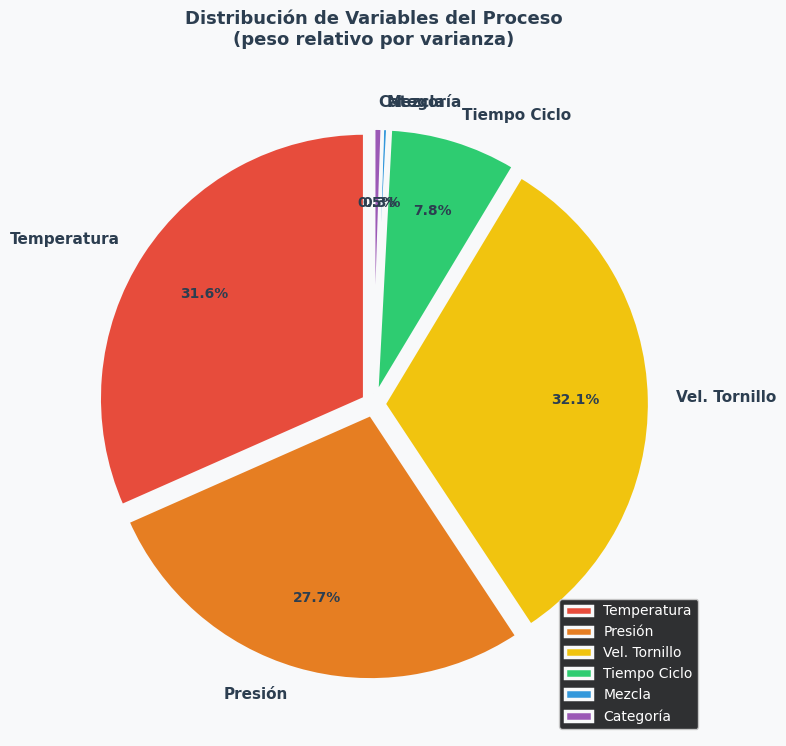

In [6]:
feature_weights = np.std(X, axis=0)
feature_weights = feature_weights / feature_weights.sum()

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("#f8f9fa")

wedges, texts, autotexts = ax.pie(
    feature_weights,
    labels=FEATURE_LABELS,
    autopct="%1.1f%%",
    colors=FEATURE_COLORS,
    startangle=90,
    explode=[0.04] * len(FEATURES),
    pctdistance=0.72,
    textprops={"fontsize": 11, "color": "#2c3e50", "fontweight": "bold"},
    wedgeprops={"edgecolor": "#f8f9fa", "linewidth": 2.5},
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
    at.set_color("#2c3e50")

ax.set_title(
    "Distribución de Variables del Proceso\n(peso relativo por varianza)",
    fontsize=13, fontweight="bold", pad=20, color="#2c3e50"
)
ax.legend(loc="lower right", fontsize=10, framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.show()


## 4. Entrenamiento de modelos

In [7]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM" : SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
}

metrics = {}
y_predictions = {}

for name, model in models.items():
    X_tr = X_train if name == "Random Forest" else X_train_sc
    X_te = X_test  if name == "Random Forest" else X_test_sc

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_predictions[name] = y_pred

    metrics[name] = {
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred, zero_division=0),
        "F1-Score" : f1_score(y_test, y_pred, zero_division=0),
        "Accuracy" : accuracy_score(y_test, y_pred),
    }

print("Entrenamiento completado.")


Entrenamiento completado.


## 5. Resultados

In [8]:
for name in models:
    print(f"\n{'─'*50}  {name}  {'─'*50}")
    print(classification_report(
        y_test, y_predictions[name],
        target_names=["Con defecto (0)", "Sin defecto (1)"],
        zero_division=0
    ))



──────────────────────────────────────────────────  Random Forest  ──────────────────────────────────────────────────
                 precision    recall  f1-score   support

Con defecto (0)       1.00      0.69      0.82        29
Sin defecto (1)       0.95      1.00      0.98       188

       accuracy                           0.96       217
      macro avg       0.98      0.84      0.90       217
   weighted avg       0.96      0.96      0.96       217


──────────────────────────────────────────────────  SVM  ──────────────────────────────────────────────────
                 precision    recall  f1-score   support

Con defecto (0)       0.73      0.38      0.50        29
Sin defecto (1)       0.91      0.98      0.94       188

       accuracy                           0.90       217
      macro avg       0.82      0.68      0.72       217
   weighted avg       0.89      0.90      0.88       217


──────────────────────────────────────────────────  KNN  ────────────────────────

### 5.1 Matrices de confusión

Una matriz por algoritmo. Las filas representan la clase **real** y las columnas la clase **predicha**.


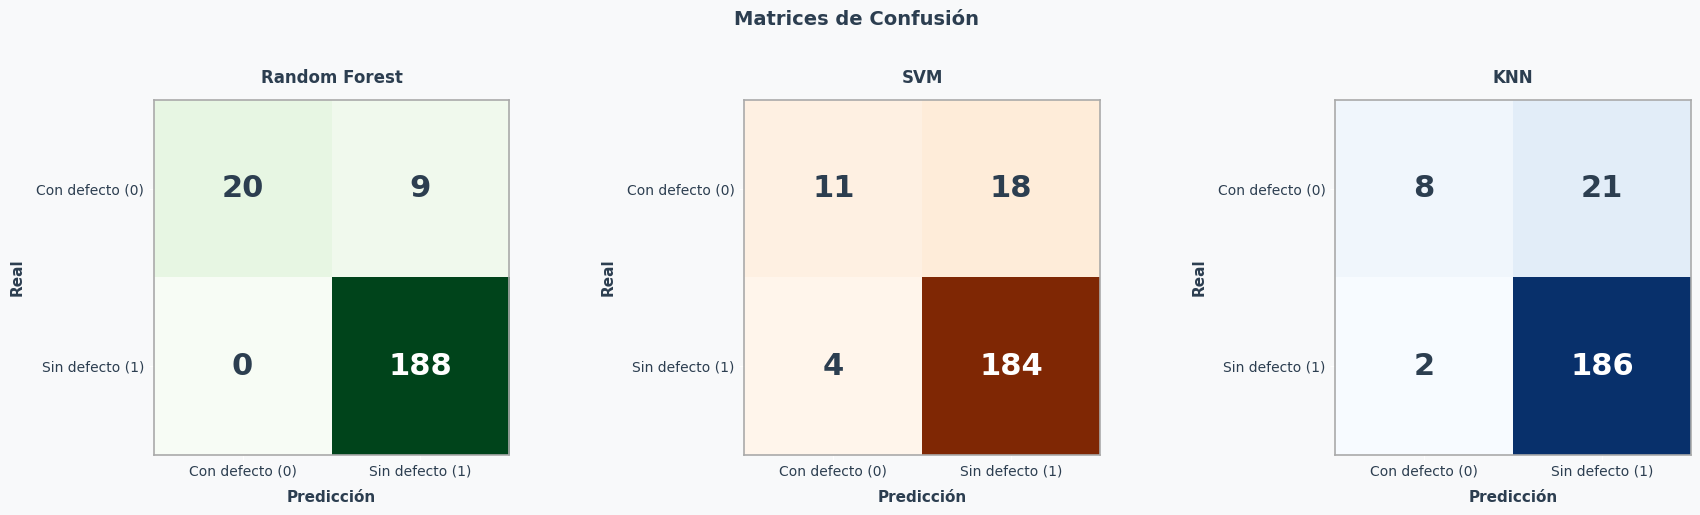

In [9]:
cmap_per_model = {
    "Random Forest": plt.cm.Greens,
    "SVM"          : plt.cm.Oranges,
    "KNN"          : plt.cm.Blues,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#f8f9fa")
fig.suptitle("Matrices de Confusión", fontsize=14, fontweight="bold", y=1.02, color="#2c3e50")

for ax, name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(y_test, y_predictions[name])
    ax.imshow(cm, interpolation="nearest", cmap=cmap_per_model[name])

    ax.set_title(name, fontweight="bold", pad=12, fontsize=12, color="#2c3e50")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Con defecto (0)", "Sin defecto (1)"], fontsize=10, color="#2c3e50")
    ax.set_yticklabels(["Con defecto (0)", "Sin defecto (1)"], fontsize=10, color="#2c3e50")
    ax.set_xlabel("Predicción", fontweight="bold", fontsize=11, color="#2c3e50", labelpad=8)
    ax.set_ylabel("Real", fontweight="bold", fontsize=11, color="#2c3e50", labelpad=8)

    for spine in ax.spines.values():
        spine.set_edgecolor("#aaaaaa")
        spine.set_linewidth(1.2)

    cm_max = cm.max()
    for i in range(2):
        for j in range(2):
            txt_color = "white" if cm[i, j] > cm_max * 0.6 else "#2c3e50"
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=22, fontweight="bold",
                    color=txt_color)

plt.tight_layout()
plt.show()


### 5.2 Comparación de métricas por algoritmo

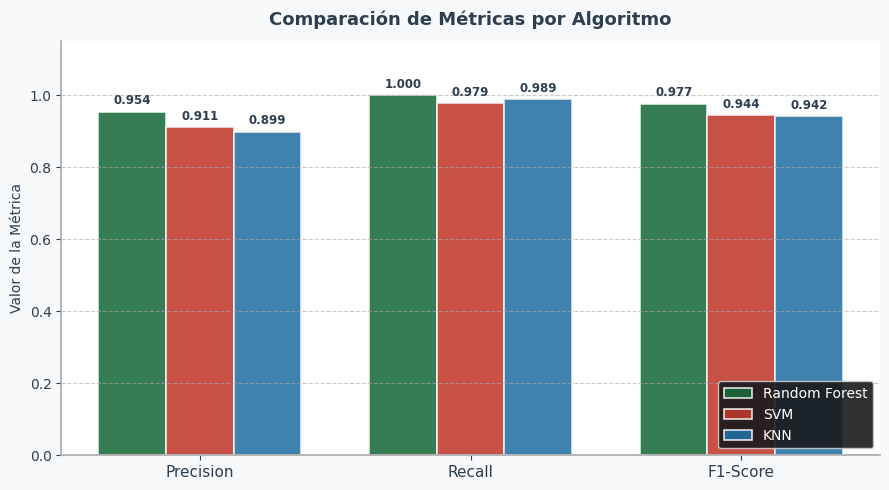

In [10]:
metric_names = ["Precision", "Recall", "F1-Score"]
x_pos = np.arange(len(metric_names))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#f8f9fa")
ax.set_facecolor("#ffffff")

for i, (name, color) in enumerate(zip(MODEL_NAMES, MODEL_COLORS)):
    vals = [metrics[name][m] for m in metric_names]
    bars = ax.bar(x_pos + i * w, vals, w, label=name, color=color,
                  alpha=0.88, edgecolor="#f8f9fa", linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{val:.3f}",
            ha="center", va="bottom",
            fontsize=8.5, fontweight="bold", color="#2c3e50"
        )

ax.set_title("Comparación de Métricas por Algoritmo",
             fontsize=13, fontweight="bold", color="#2c3e50", pad=12)
ax.set_xticks(x_pos + w)
ax.set_xticklabels(metric_names, fontsize=11, color="#2c3e50")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor de la Métrica", color="#2c3e50", fontsize=10)
ax.tick_params(colors="#2c3e50")
ax.legend(loc="lower right", fontsize=10, framealpha=0.9, edgecolor="#cccccc")
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6, color="#aaaaaa")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_edgecolor("#aaaaaa")
ax.spines[["left", "bottom"]].set_linewidth(1.2)

plt.tight_layout()
plt.show()


### 5.3 Exactitud global por algoritmo

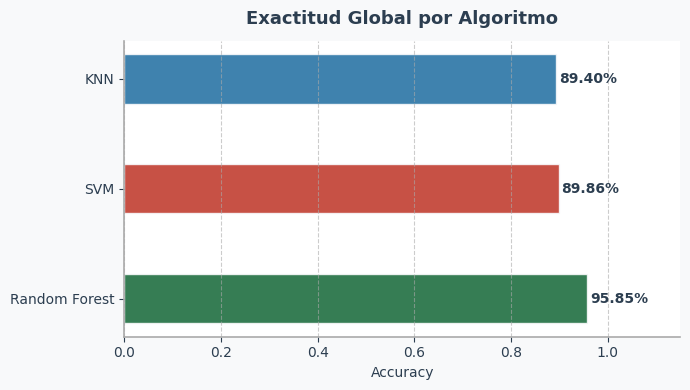

In [11]:
accuracies = [metrics[n]["Accuracy"] for n in MODEL_NAMES]

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("#f8f9fa")
ax.set_facecolor("#ffffff")

bars = ax.barh(MODEL_NAMES, accuracies, color=MODEL_COLORS,
               alpha=0.88, edgecolor="#f8f9fa", height=0.45)
for bar, val in zip(bars, accuracies):
    ax.text(
        val + 0.006,
        bar.get_y() + bar.get_height() / 2,
        f"{val*100:.2f}%",
        va="center", fontsize=10, fontweight="bold", color="#2c3e50"
    )

ax.set_title("Exactitud Global por Algoritmo",
             fontsize=13, fontweight="bold", color="#2c3e50", pad=12)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Accuracy", color="#2c3e50", fontsize=10)
ax.tick_params(colors="#2c3e50")
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.6, color="#aaaaaa")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_edgecolor("#aaaaaa")
ax.spines[["left", "bottom"]].set_linewidth(1.2)

plt.tight_layout()
plt.show()
